<a href="https://colab.research.google.com/github/annhater/M1_STAGE/blob/main/2_notebooks/03_plot_env25_heatmap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [101]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [102]:
#IMPORTS
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [103]:
#SETUP
rootdir = '/content/drive/MyDrive/M1_STAGE/Manips/Tables/'
os.chdir(rootdir)

In [104]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#MAIN
# 1. Extract frequency data

# 1. Read data

# 1.0. Setup
df_list = []
CA_atoms = []
simulation_names = ['V1', 'V11', 'V12', 'V7', 'V8', 'V21']
all_results = {}
residue_dico = {}
# Initialize a set to collect all unique atom identifiers across all simulations
all_unique_atom_identifiers = set()

# 1.1. Open frequency tables, read as df
freq_df_paths = [
    "V1_ASP_env_atoms_frequency.csv",
    "V11_ASP_env_atoms_frequency.csv",
    "V12_ASP_env_atoms_frequency.csv",
    "V7_ASP_env_atoms_frequency.csv",
    "V8_ASP_env_atoms_frequency.csv",
    "V21_ASP_env_atoms_frequency.csv"
]
for sim in freq_df_paths:
    sim_name = sim.replace("_ASP_env_atoms_frequency.csv", "")
    df_sim = pd.read_csv(sim)

    # 1.2. Filter only alpha carbons (and that are not Asp25 alpha carbon)
    filtered_CA = df_sim[
        df_sim["Residue"].apply(lambda x: 'CA' in x and 'ASP_25' not in x)
        ].copy()

    # 1.3. Save to new df for graph parameters
    df_new = pd.DataFrame()
    df_new["Atom_Identifier"] = filtered_CA["Residue"] # Keep the full atom identifier
    df_new["Frequency"] = filtered_CA['Frequency']

    # 1.3.1. For each atom, get its residue_id, chain, and atom_name
    chain_label_list = []
    res_id_list = []
    atom_name_list = []


    for atom in filtered_CA["Residue"].values:
        res_str = atom.split('_')
        atom_id = int(res_str[0])
        res_id = '_'.join(res_str[2:])
        atom_name = res_str[1]
        if atom_id < 1536:
            chain_label_list.append("Chain A")
        else:
            chain_label_list.append("Chain B")
        res_id_list.append(res_id)
        # Collect all unique atom identifiers in the global set
        atom_name_list.append(atom_name)
        all_unique_atom_identifiers.add(atom) # Add to the global set

    df_new["Chain"] = chain_label_list
    df_new["Residue_Id"] = res_id_list
    df_new["Atom"] = atom_name_list
    # The 'Atom_Identifier' column is intentionally NOT dropped here.

    all_results[sim_name] = df_new

In [105]:
all_results

{'V1':     Atom_Identifier  Frequency    Chain Residue_Id Atom
 20   1919_CA_LEU_24    100.000  Chain B     LEU_24   CA
 42   1964_CA_GLY_27    100.000  Chain B     GLY_27   CA
 51   1950_CA_THR_26    100.000  Chain B     THR_26   CA
 66    1666_CA_ARG_8     97.403  Chain B      ARG_8   CA
 83   2922_CA_LEU_90     97.203  Chain B     LEU_90   CA
 110  2838_CA_PHE_85     96.404  Chain B     PHE_85   CA
 123  1971_CA_ALA_28     92.907  Chain B     ALA_28   CA
 132  2819_CA_ILE_84     92.707  Chain B     ILE_84   CA
 149  2858_CA_GLY_86     90.509  Chain B     GLY_86   CA
 169  1330_CA_ARG_87     70.929  Chain A     ARG_87   CA
 180  1900_CA_LEU_23     60.340  Chain B     LEU_23   CA
 197  2865_CA_ARG_87     15.185  Chain B     ARG_87   CA
 228   1698_CA_PRO_9     12.987  Chain B      PRO_9   CA
 244  1484_CA_LEU_97      2.198  Chain A     LEU_97   CA
 257   415_CA_THR_26      0.699  Chain A     THR_26   CA
 273  2991_CA_MET_95      0.500  Chain B     MET_95   CA
 296     66_CA_LEU_5     

In [106]:
for sim in all_results.keys():
    dataset = all_results[sim]
    dataset = dataset.set_index("Residue_Id").drop(["Chain"], axis=1)

    sns.heatmap(dataset,
            #annot=True,       # Shows the % values in the boxes
            #fmt=".1f",        # 1 decimal point
            cmap="RdYlGn",
            square=True,
            cbar=True,
            #linewidths=0.3)
            )
    plt.show()
#ax.set_aspect(freq_percent.shape[1] / freq_percent.shape[0])
plt.title("Frequency of interactions with Asp25", fontsize=16)
plt.ylabel("Simulation")
plt.xlabel("Residue (within 5A)")
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()



ValueError: could not convert string to float: '1919_CA_LEU_24'

In [ ]:
all_residues

In [118]:
# The 'atom_data_df' created in cell 'e0f79337' contains the 'Descriptive_Label' column
# Define the list of unique descriptive labels for the heatmap columns
all_residues = atom_data_df['Descriptive_Label'].unique().tolist()

# Initialize the heatmap_data DataFrame with simulation names as index and merged descriptive labels as columns
heatmap_data = pd.DataFrame(index=simulation_names, columns=all_residues)

# Populate the heatmap_data by aggregating frequencies for each simulation
for sim_name in simulation_names:
    # Get the raw frequency data for the current simulation
    df_sim_raw = all_results[sim_name].copy()

    # Add the Descriptive_Label column to this simulation's DataFrame if it doesn't exist
    # This ensures consistency with how 'all_residues' was generated
    descriptive_labels_for_sim = []
    for atom_identifier in df_sim_raw['Atom_Identifier']:
        parts = atom_identifier.split('_')
        atom_id_val = int(parts[0])
        atom_name = parts[1]
        residue_type = parts[2]
        residue_num = parts[3]
        chain_label = 'chA' if atom_id_val < 1536 else 'chB'
        descriptive_labels_for_sim.append(f"{atom_name}_{residue_type}{residue_num}_{chain_label}")
    df_sim_raw['Descriptive_Label'] = descriptive_labels_for_sim

    # Group by the Descriptive_Label and take the maximum frequency
    merged_frequencies = df_sim_raw.groupby('Descriptive_Label')['Frequency'].max()

    # Assign these merged frequencies to the correct row in heatmap_data
    for label, freq in merged_frequencies.items():
        if label in heatmap_data.columns: # Ensure the label exists in our defined columns
            heatmap_data.loc[sim_name, label] = freq

# Convert to float to handle NaN values properly
heatmap_data = heatmap_data.astype(float)

# Sort the columns (residues) alphabetically for consistent display
heatmap_data = heatmap_data.reindex(columns=sorted(heatmap_data.columns))

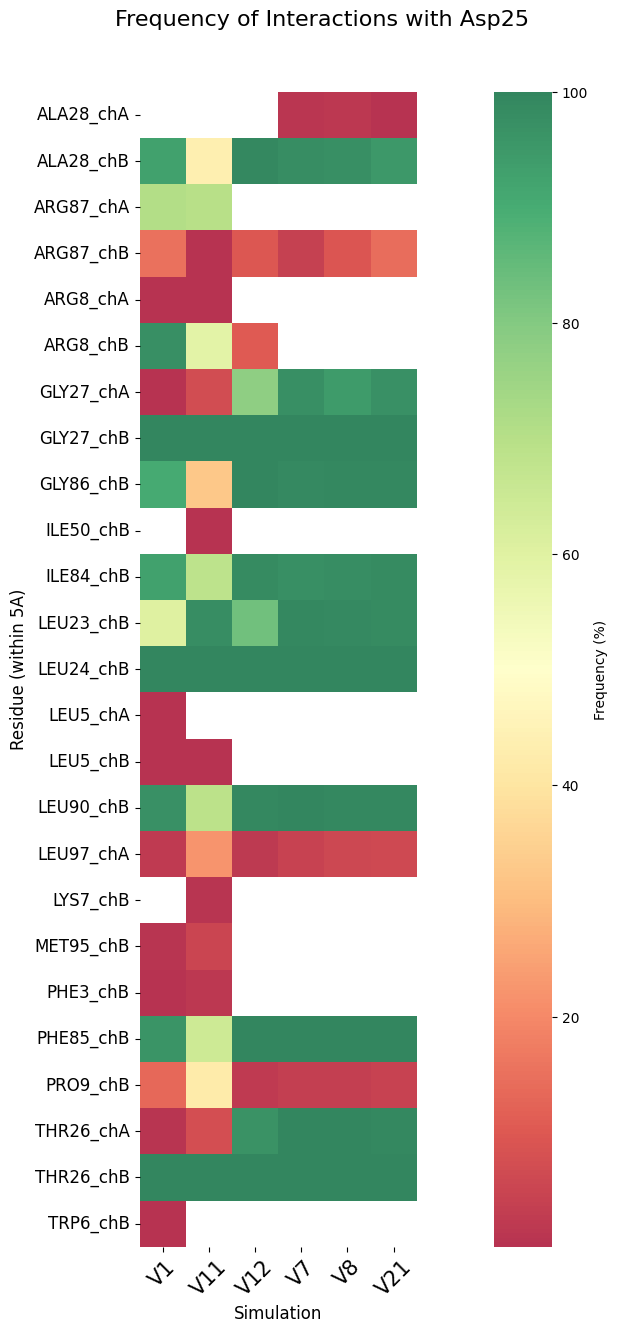

In [119]:
fig, ax = plt.subplots(figsize=(20, 15)) # Significantly increased figure height for larger squares and better visibility

sns.heatmap(heatmap_data.T, # Transpose the DataFrame to swap axes
            annot=False,        # Keep as False for now to avoid clutter with many small cells
            fmt=".1f",          # Format for annotations
            cmap="RdYlGn",      # Color map (green for high frequency, red for low)
            square=True,       # Set to True if you want squares to be equal size
            cbar=True,  # Color of the lines between cells
            ax=ax,              # Pass the ax object to sns.heatmap
            cbar_kws={'label': 'Frequency (%)'},
            #linecolor="black", # Uncomment if you want black lines between cells
            #linewidths=0.5,    # Uncomment if you want lines between cells
            alpha=0.8
            )

plt.title("Frequency of Interactions with Asp25", fontsize=16, y=1.05, x=0.66)
plt.xlabel("Simulation", fontsize=12) # Swapped x-axis label
plt.ylabel("Residue (within 5A)", fontsize=12) # Swapped y-axis label

# Use the 'all_residues' (which now contains the unique descriptive labels) directly for y-axis labels
formatted_y_labels = heatmap_data.columns.tolist() # Get the sorted columns from heatmap_data

# Remove 'CA_' prefix from the labels
formatted_y_labels = [label.replace('CA_', '') for label in formatted_y_labels]

plt.yticks(ticks=[x + 0.5 for x in range(len(formatted_y_labels))], labels=formatted_y_labels, rotation=0, fontsize=12) # Apply to y-axis with appropriate rotation, slightly increased fontsize
plt.xticks(ticks=[x + 0.5 for x in range(len(simulation_names))], labels=simulation_names, rotation=45, fontsize=15) # Apply to x-axis, using simulation_names
#plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

In [109]:
import pandas as pd

# Prepare a list to store parsed atom data
all_atom_data = []

# Iterate through all_results to gather and parse atom identifiers
for sim_name, df_sim_data in all_results.items():
    for _, row in df_sim_data.iterrows():
        atom_identifier = row['Atom_Identifier']
        parts = atom_identifier.split('_')
        atom_id = int(parts[0])
        atom_name = parts[1]
        residue_type = parts[2]
        residue_num = parts[3]

        chain_label = 'chA' if atom_id < 1536 else 'chB'

        # Create a 'descriptive_label' that excludes the atom_id
        descriptive_label = f"{atom_name}_{residue_type}{residue_num}_{chain_label}"

        all_atom_data.append({
            'Atom_Identifier_Full': atom_identifier,
            'Atom_ID': atom_id,
            'Descriptive_Label': descriptive_label,
            'Simulation': sim_name
        })

# Create a DataFrame from the collected data
atom_data_df = pd.DataFrame(all_atom_data)

# Group by Descriptive_Label and check for multiple unique Atom_IDs
duplicate_label_groups = atom_data_df.groupby('Descriptive_Label').filter(lambda x: x['Atom_ID'].nunique() > 1)

# Sort the results for better readability
duplicate_label_groups = duplicate_label_groups.sort_values(by=['Descriptive_Label', 'Atom_ID'])

print("Atoms with the same descriptive label but different Atom_IDs (potential shifts):")
display(duplicate_label_groups[['Descriptive_Label', 'Atom_ID', 'Atom_Identifier_Full', 'Simulation']])

Atoms with the same descriptive label but different Atom_IDs (potential shifts):


,Descriptive_Label,Atom_ID,Atom_Identifier_Full,Simulation
6,CA_ALA28_chB,1971,1971_CA_ALA_28,V1
31,CA_ALA28_chB,1971,1971_CA_ALA_28,V11
49,CA_ALA28_chB,1971,1971_CA_ALA_28,V12
67,CA_ALA28_chB,1972,1972_CA_ALA_28,V7
83,CA_ALA28_chB,1972,1972_CA_ALA_28,V8
99,CA_ALA28_chB,1972,1972_CA_ALA_28,V21
11,CA_ARG87_chB,2865,2865_CA_ARG_87,V1
43,CA_ARG87_chB,2865,2865_CA_ARG_87,V11
56,CA_ARG87_chB,2865,2865_CA_ARG_87,V12
71,CA_ARG87_chB,2866,2866_CA_ARG_87,V7
